In [7]:
import pandas as pd

In [8]:
# Importando o arquivo

data_clientes = pd.read_csv('../data/emp_automovel.csv')
data_clientes.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.0,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.0,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.0,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.0,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.0,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0


In [9]:
data_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [10]:
# Separando as variaveis de categoria entre explicativas e alvo
x = data_clientes.drop('inadimplente', axis=1)
y = data_clientes['inadimplente']

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

x, x_teste, y, y_teste = train_test_split(x, y, test_size=0.15, stratify=y, random_state=5) #porcentagem para separar os dados
x_treino, x_val, y_treino, y_val = train_test_split(x,y, stratify=y, random_state=5)


In [12]:
modelo_arvore = DecisionTreeClassifier(max_depth=10)
modelo_arvore.fit(x_treino, y_treino)

print(f'Acuracia de treino:{modelo_arvore.score(x_treino,y_treino)}')
print(f'Acuracia de validacao:{modelo_arvore.score(x_val,y_val)}')

Acuracia de treino:0.9206445993031359
Acuracia de validacao:0.9057573382109573


In [13]:
from sklearn.metrics import confusion_matrix
y_previsto = modelo_arvore.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(matriz_confusao)

[[10357   122]
 [  960    42]]


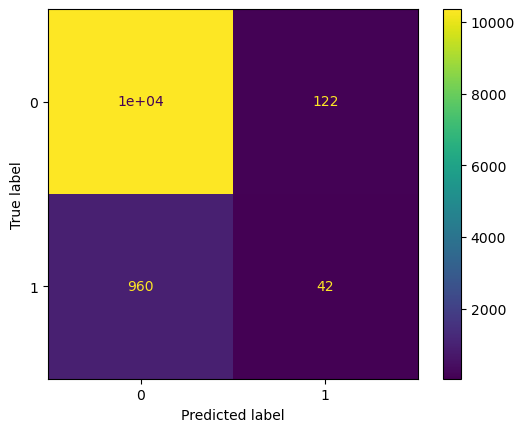

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot()

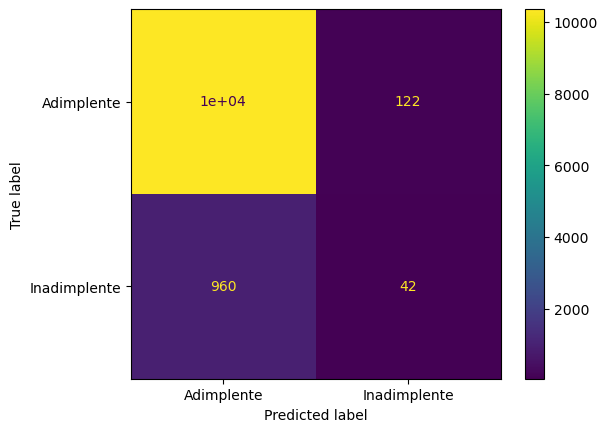

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente','Inadimplente'])
visualizacao.plot()

In [16]:
from sklearn.metrics import accuracy_score

print('Acuracia:', accuracy_score(y_val, y_previsto))

Acuracia: 0.9057573382109573


In [17]:
from sklearn.metrics import precision_score, recall_score

#calculo da precisao

print(f'Precisao: {precision_score(y_val, y_previsto)}')

#calculo do recall

print(f'Recall: {recall_score(y_val, y_previsto)}')


Precisao: 0.25609756097560976
Recall: 0.041916167664670656


In [18]:
from sklearn.metrics import f1_score

print(f'F1-Score: {f1_score(y_val, y_previsto)}')

F1-Score: 0.07204116638078903


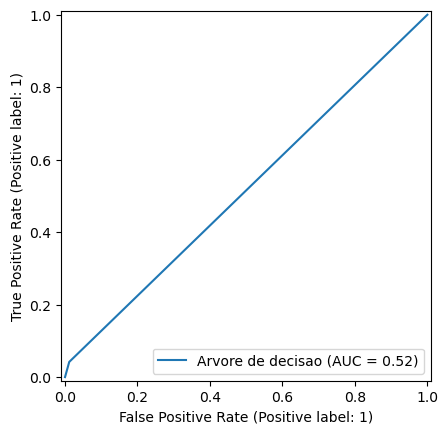

In [20]:
# Curva roc - diferencia bem os clientes adimplentes dos inadimplentes

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_val, y_previsto, name='Arvore de decisao')



In [23]:
from sklearn.metrics import roc_auc_score

print(f'AUC: {roc_auc_score(y_val, y_previsto)}')

AUC: 0.5151369176905278


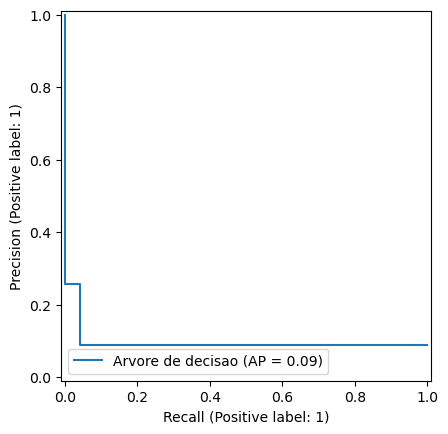

In [24]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name='Arvore de decisao')

In [28]:
from sklearn.metrics import average_precision_score

print(f'AP: {average_precision_score(y_val, y_previsto)}')


AP: 0.0943510380247745


In [ ]:
# Relatorio com todos os metodos de avaliação 

from sklearn.metrics import classification_report

print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.26      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.59      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481

